# Power analysis attack on AES with custom SBox 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
import serial.tools.list_ports as port_list
import sys
sys.path.append( '../AES_python' )
sys.path.append( '../sca_python' )
sys.path.append( '../x-heep' )

import readFirmware

ports = list(port_list.comports())
for p in ports:
    print (p)

# An already generated bitstream is available in the repository at the path:
bitstream = r"../../hw/fpga/bitstream/xheep/cw305_top.bit"
# Alternatively, you can generate the bitstream yourself by running the following command:
#   make vivado-fpga
# and the generated bitstream will be available at the path:
#bitstream = r"../../hw/vendor/cw305-heep/build/polito_cw305_heep_cw305_heep_0.0.1/cw305-vivado/polito_cw305_heep_cw305_heep_0.0.1.runs/impl_1/cw305_top.bit"
# Note that this folder is temporary and will be deleted when you run the 'make clean' command.

verilog_defines = r"../../hw/vendor/cw305-heep/hw/fpga/cw305_aes_defines.v"
firmware = r"../../hw/vendor/cw305-heep/sw/build/main.hex"

tested_sbox = "sbox_aes"
sbox_id = tested_sbox.replace("sbox_", "")
project_file = "../../build/xheep_test/xheep_test_CW305_"+sbox_id+".cwp"


/dev/ttyS4 - n/a
/dev/ttyS31 - n/a
/dev/ttyS30 - n/a
/dev/ttyS29 - n/a
/dev/ttyS28 - n/a
/dev/ttyS27 - n/a
/dev/ttyS26 - n/a
/dev/ttyS25 - n/a
/dev/ttyS24 - n/a
/dev/ttyS23 - n/a
/dev/ttyS22 - n/a
/dev/ttyS21 - n/a
/dev/ttyS20 - n/a
/dev/ttyS19 - n/a
/dev/ttyS18 - n/a
/dev/ttyS17 - n/a
/dev/ttyS16 - n/a
/dev/ttyS15 - n/a
/dev/ttyS14 - n/a
/dev/ttyS13 - n/a
/dev/ttyS12 - n/a
/dev/ttyS11 - n/a
/dev/ttyS10 - n/a
/dev/ttyS9 - n/a
/dev/ttyS8 - n/a
/dev/ttyS7 - n/a
/dev/ttyS6 - n/a
/dev/ttyS5 - n/a
/dev/ttyS3 - n/a
/dev/ttyS2 - n/a
/dev/ttyS1 - n/a
/dev/ttyS0 - n/a
/dev/ttyUSB4 - FT232R USB UART - FT232R USB UART


In [2]:
print("bitstream: ", bitstream)
print("firmware: ", firmware)
print("verilog_defines: ", verilog_defines)
print("project_file: ", project_file)

bitstream:  ../../hw/fpga/bitstream/xheep/cw305_top.bit
firmware:  ../../hw/vendor/cw305-heep/sw/build/main.hex
verilog_defines:  ../../hw/vendor/cw305-heep/hw/fpga/cw305_aes_defines.v
project_file:  ../../build/xheep_test/xheep_test_CW305_aes.cwp


In [3]:
from picoscope import ps5000a
import chipwhisperer as cw
import time
from picosdk.discover import find_all_units

import os
os.system("pip list | grep chipwhisperer")



chipwhisperer                     5.7.0


You should consider upgrading via the '/home/lorenzo_capobianco/.pyenv/versions/3.9.5/bin/python3.9 -m pip install --upgrade pip' command.


0

## Picoscope and CW305 initialization

In [4]:
from pico_api import PS5000aWrapper

try:
    # Initialize picoscope
    ps = PS5000aWrapper()
    ps.get_unitInfo()
    ps.scope_setup(obs_time=1E-4, nSamples=40000) # 1ms time window, 400k samples which results in 2 ns sampling interval. Much higher than the 10 MHz clock frequency for X-HEEP.

    # Initialize CW305 with required parameters. More in detail:
    # ps: picoscope object
    # cw.targets.CW305: target device
    # bsfile: bitstream file
    # force: force programming
    # slurp: used to get the device verilog defines for the register addresses
    # defines_files: verilog defines file path.
    cw305 = cw.target(None, cw.targets.CW305, bsfile=bitstream, force=True, slurp=True, defines_files=[verilog_defines])
    cw305.vccint_set(1.0)
    cw305.pll.pll_enable_set(True)             # enable PLL chip
    cw305.pll.pll_outenable_set(False, 0)      # disable PLL 0
    cw305.pll.pll_outenable_set(True, 1)       # enable PLL 1
    cw305.pll.pll_outenable_set(False, 2)      # disable PLL 2
    cw305.pll.pll_outfreq_set(10E6, 1)         # PLL1 frequency set to 10 MHz
    # Disable usb_clock. Optional, but reduces power trace noise
    cw305.clkusbautooff = True
    # 1 ms is plenty idling time 
    cw305.clksleeptime = 1

    # Set the clock source writing the corresponding register
    cw305.fpga_write(cw305.REG_CLKSETTINGS, data=bytearray([0x01]))
    # DEBUG
    # print("FPGA CLKSETTINGS REGISTER: ", cw305.fpga_read(cw305.REG_CLKSETTINGS, 1)[::-1])

    # Load firmware
    readFirmware.readFirmware(cw305, firmware)
    
except ModuleNotFoundError as e:
    print(e)

Found the following picoscope:
DriverVersion                 : PS5000A Linux Driver, 2.2.7.5057
USBVersion                    : 3.0
HardwareVersion               : 1
VariantInfo                   : 5244D
BatchAndSerial                : KU687/0175
CalDate                       : 26Apr23
KernelVersion                 : 0.0
DigitalHardwareVersion        : 1
AnalogueHardwareVersion       : 1
PicoFirmwareVersion1          : 1.7.15.0
PicoFirmwareVersion2          : 1.2.36.0

Firmware file '../../hw/vendor/cw305-heep/sw/build/main.hex' found. Loading firmware...


...Firmware loaded. Setting boot exit loop flag...


...Done



In [5]:
print(ps.get_scopeSettings())
print()
print("Sampling Interval: ", ps.get_samplingInterval(), "s")

Nsamples :  50000
Sampling interval = %f us 2e-09
Channel A settings:  Channel A: Range = 50mV, AC coupling, 20 MHz BW limit
Channel B settings:  Channel B: Range = 10V, DC coupling, trigger
None

Sampling Interval:  2e-09 s


In [6]:
# Write 8 to the status register to trigger the program execution and the scope acquisition
#cw305.fpga_write(cw305.REG_BRIDGE_STATUS, data=bytearray([0x08]))

In [7]:
#cw305.fpga_write(cw305.REG_BRIDGE_STATUS, data=bytearray([0x00]))

## Online phase : AES power traces capture

In [ ]:
from tqdm.notebook import tnrange
#import chipwhisperer as cw
from chipwhisperer.common.traces import Trace
from Crypto.Cipher import AES
from AES_golden import AES_golden_model

project = cw.create_project(project_file, overwrite=True)

# Initialize key and plain text
key  = [ 0x2b, 0x7e, 0x15, 0x16, 0x28, 0xae, 0xd2, 0xa6, 0xab, 0xf7, 0x15, 0x88, 0x09, 0xcf, 0x4f, 0x3c ]
# key  = [ 0x3c, 0x8f, 0x26, 0x27, 0x39, 0xbf, 0xe3, 0xb1, 0xbc, 0x08, 0x26, 0x99, 0x1a, 0xd0, 0x52, 0x4d ]
text = [ 0x6e, 0xc1, 0x53, 0x9c, 0xfb, 0xe7, 0xf6, 0x18, 0x92, 0xac, 0x19, 0x87, 0xf5, 0x94, 0xe1, 0x2b ]

# Each element of the key is converted to a 2-digit hex string 
formatted_key = ''.join(format(el, '02x') for el in key)
print("Key: ", [ hex(subkey) for subkey in key])

# Initialize the AES software emulated cipher
cipher = AES_golden_model()

# Number of traces to capture
N = 150

for i in tnrange(N, desc='Capturing traces'):
    # Run the target
    ps.runBlock()
    time.sleep(0.05)

    # Write 8 to the status register to trigger the program execution and the scope acquisition
    cw305.fpga_write(cw305.REG_BRIDGE_STATUS, data=bytearray([0x08]))

    ps.waitReady()

    # Get captured trace 
    data = ps.getDataV()

    # trace = Trace(np.array(data), pt, response, self.key)
    trace = Trace(np.array(data), text, cipher.encrypt(formatted_key, text, tested_sbox), key)
    project.traces.append(trace)
    print("Cipertext: ", [ hex(subkey) for subkey in cipher.encrypt(formatted_key, text, tested_sbox)])
    
    # Update the plain text as the previous chipertext
    text = cipher.encrypt(formatted_key, text, tested_sbox)

    time.sleep(1E-3) # 1 ms
    # Reset the status register to reload the program execution and the scope acquisition
    cw305.fpga_write(cw305.REG_BRIDGE_STATUS, data=bytearray([0x00]))

project.save()
project.close()
# Disconnect CW305 and picoscope
cw305.dis()
ps.dis()

Key:  ['0x3c', '0x8f', '0x26', '0x27', '0x39', '0xbf', '0xe3', '0xb1', '0xbc', '0x8', '0x26', '0x99', '0x1a', '0xd0', '0x52', '0x4d']


Capturing traces:   0%|          | 0/150 [00:00<?, ?it/s]

Cipertext:  ['0xc8', '0x23', '0xcc', '0xfc', '0x44', '0x97', '0x27', '0xa7', '0xde', '0x46', '0x6c', '0xab', '0xcf', '0xfe', '0x72', '0x66']
Cipertext:  ['0x1c', '0xd', '0xb5', '0x6b', '0x20', '0x63', '0xfc', '0xf5', '0x91', '0x80', '0xb7', '0x86', '0x7c', '0x19', '0x14', '0x8f']
Cipertext:  ['0xbf', '0x58', '0x65', '0x44', '0x7e', '0x1d', '0x1a', '0x15', '0xed', '0xf4', '0x18', '0x4c', '0xb4', '0x48', '0xe', '0x84']
Cipertext:  ['0x99', '0x15', '0x20', '0xf9', '0x3d', '0x1b', '0xec', '0xc9', '0x60', '0x7a', '0x24', '0x56', '0xb', '0x3a', '0x83', '0xc8']
Cipertext:  ['0xc5', '0x1e', '0x4', '0x8f', '0x42', '0xd1', '0x23', '0x96', '0xcd', '0xae', '0x42', '0xb1', '0xb3', '0x5f', '0xef', '0x37']
Cipertext:  ['0xee', '0xcc', '0x5e', '0xc8', '0x5c', '0xaa', '0xe5', '0x47', '0x8e', '0x39', '0x51', '0xd', '0xe9', '0x20', '0x8d', '0x92']
Cipertext:  ['0x51', '0xcf', '0x2c', '0xff', '0xf2', '0xfc', '0x0', '0x37', '0x2c', '0x5a', '0x37', '0x74', '0x63', '0x74', '0xd6', '0x95']
Cipertext:  ['0xeb'

## Offline phase : attack on captured traces

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
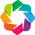

In [9]:
import os
import chipwhisperer.analyzer as cwa
import chipwhisperer as cw
import holoviews as hv
hv.extension('bokeh')
from analyzer.attack.aes.SBox_leakage_models import AES128SboxResistantLeakageModels
from analyzer.attack.aes.key_schedule import key_schedule_rounds
from analyzer.utils.sca_plots import sca_plot

sca_plt = sca_plot()
project = cw.open_project(project_file)

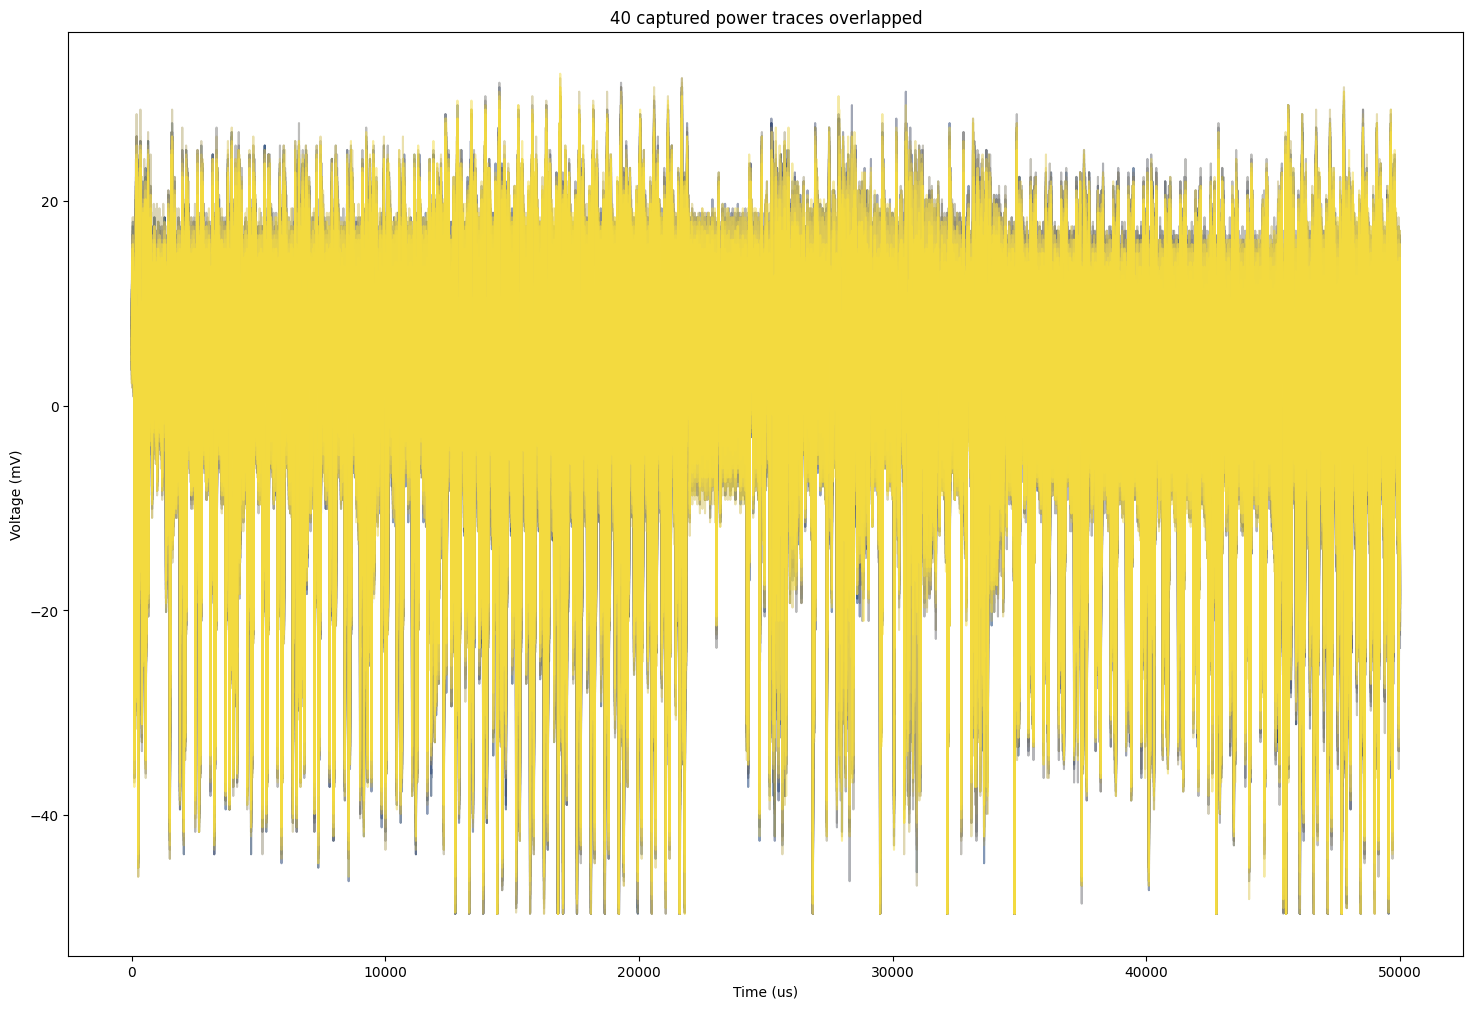

In [10]:
power_plt = sca_plt.power_traces_overlapped(ps.get_samplingInterval(), project.waves, finish=len(project.waves[0]))
power_plt.show()
# Ensure the Graphs directory exists
# os.makedirs("Graphs", exist_ok=True)
# power_plt.savefig("Graphs/power_traces_overlapped"+tested_sbox+".png")

In [12]:
cw.plot(project.waves[0])

/home/lorenzo_capobianco/.pyenv/versions/3.9.5/lib/python3.9/site-packages/holoviews/core/data/pandas.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return dataset.data.dtypes[idx].type
/home/lorenzo_capobianco/.pyenv/versions/3.9.5/lib/python3.9/site-packages/holoviews/core/data/pandas.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return dataset.data.dtypes[idx].type


:Curve   [x]   (y)

### SNR evaluation : detect leakage points

In [ ]:
#leak_model = cwa.leakage_models.sbox_output
#project.traces.extend(project.traces)

# First round sbox output snr calculation
leak_model = AES128SboxResistantLeakageModels().FirstRound_ModifiedSbox_Output(tested_sbox)
snr_fr = cwa.calculate_snr(project.traces, leak_model=leak_model, db=False)
curve = hv.Curve(snr_fr).opts(height=600, width=600, color='orange', alpha=0.5)
# Last round state diff snr calculation
leak_model = AES128SboxResistantLeakageModels().LastroundStateDiff_ModifiedSbox(tested_sbox)
snr_lr = cwa.calculate_snr(project.traces, leak_model=leak_model, db=False)
curve *= hv.Curve(snr_lr).opts(height=600, width=600, color='blue', alpha=0.5)

curve.opts(width=900, height=600, show_legend=True, legend_position='right', xlabel='Sample', ylabel='SNR', title="SNR in time") 


### Hamming distance attack : state difference leakage model on last round

In [ ]:
# Recover key
recv_lastroundkey = [kguess[0][0] for kguess in results.find_maximums()]
recv_key = key_schedule_rounds(recv_lastroundkey, 10, 0, tested_sbox)
print("Recovered key: ", [hex(subkey) for subkey in recv_key])
key=list(project.keys[0])
assert (key == recv_key), "Failed to recover encryption key!\nGot {}\nExp {}\n".format(recv_key, key)
print("Key recovery : Success!")

In [11]:
leak_model = cwa.leakage_models.sbox_output
attack = cwa.cpa(project, leak_model)
cb = cwa.get_jupyter_callback(attack)
results = attack.run(cwa.get_jupyter_callback(attack, 10))
#print(results.best_guesses())

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
PGE=,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
0,3C0.586,8F0.583,260.441,270.535,390.619,BF0.594,E30.523,B10.569,BC0.547,080.573,260.501,990.565,1A0.548,D00.553,520.555,4D0.477
1,E30.395,DB0.403,610.426,EA0.441,1F0.438,7F0.395,5D0.420,F90.409,980.456,2C0.430,DE0.380,780.456,940.455,F80.399,8D0.382,1A0.390
2,4A0.391,CC0.381,B40.411,300.395,B90.387,170.381,EA0.409,A10.401,F40.379,4E0.400,480.377,450.406,E00.439,600.383,880.379,C20.390
3,FD0.380,640.376,530.405,C10.392,9A0.381,350.380,8A0.403,650.393,9F0.375,B10.394,2F0.374,110.405,620.430,250.380,5C0.378,280.383
4,DC0.374,D50.376,C00.404,630.390,860.381,890.377,F30.392,020.385,A70.370,070.380,490.373,2B0.398,8A0.401,240.376,7B0.376,450.378
5,F00.373,A60.375,010.400,D50.380,870.361,000.377,C40.389,480.380,FF0.366,310.374,470.369,E90.379,680.386,860.374,DF0.376,B10.376
6,C90.372,E40.374,A70.389,9F0.375,110.359,220.375,A90.379,230.376,310.366,550.371,EC0.368,E20.374,B90.383,750.371,7D0.368,A70.370
7,BF0.368,0C0.373,6C0.382,900.370,D50.356,CF0.375,920.372,520.373,7F0.365,670.366,F60.365,6E0.373,DF0.379,960.370,7A0.367,590.367
8,B90.366,6E0.370,B90.376,890.369,170.356,600.372,890.368,F50.371,600.363,EF0.363,270.364,8F0.368,A80.370,120.368,E90.360,AB0.366
